# Inizializzazione


In [3]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

Matplotlib is building the font cache; this may take a moment.


In [6]:
import pandas as pd

# I nomi delle 11 colonne del MAGIC Gamma Telescope
col_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 
             'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']

# Scarica il CSV originale aggirando l'API
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data", names=col_names)

# Separa le features dal target per mantenere la struttura del tuo vecchio codice
X = df.drop('class', axis=1)
y = df['class']

# Adesso puoi continuare col codice originale!
print("Dataset caricato con successo! Dimensioni:", X.shape)


URLError: <urlopen error [Errno 8] nodename nor servname provided, or not known>

In [7]:
import pandas as pd

# I nomi delle 11 colonne del MAGIC Gamma Telescope
col_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 
             'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']

# Legge il file in locale che ti ho appena scaricato
df = pd.read_csv("magic04.data", names=col_names)

# Separa le features dal target per mantenere la struttura del tuo vecchio codice
X = df.drop('class', axis=1)
y = df['class'].map({'h': 0, 'g': 1}) # Mappa le lettere in 0 e 1 come avevi fatto tu

# Diamo un'occhiata
print("Dataset caricato con successo in locale! Dimensioni:", X.shape)

Dataset caricato con successo in locale! Dimensioni: (19020, 10)


In [8]:
df.shape

(19020, 11)

In [9]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [10]:
df.tail()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h
19019,187.1814,53.0014,3.2093,0.2876,0.1539,-167.3125,-168.4558,31.4755,52.7310,272.3174,h


In [11]:
df.dtypes

fLength     float64
fWidth      float64
fSize       float64
fConc       float64
fConc1      float64
fAsym       float64
fM3Long     float64
fM3Trans    float64
fAlpha      float64
fDist       float64
class           str
dtype: object

In [12]:
# Imposto il target come categorico
df["class"] = df["class"].astype("category")

In [13]:
df.dtypes

fLength      float64
fWidth       float64
fSize        float64
fConc        float64
fConc1       float64
fAsym        float64
fM3Long      float64
fM3Trans     float64
fAlpha       float64
fDist        float64
class       category
dtype: object

In [14]:
df['class'] = df['class'].map({'h': 0, 'g': 1})

# Verifica dei target
print(df['class'].value_counts())

class
1    12332
0     6688
Name: count, dtype: int64


# Analisi Esplorativa

## Controllo NAN e Duplicati

In [15]:
# Verifica dei valori NaN
print("Valori mancanti per colonna:")
print(df.isnull().sum())

# Verifica dei duplicati
print(f"\nDuplicati trovati: {df.duplicated().sum()}")
# Elimina duplicati
df = df.drop_duplicates()

Valori mancanti per colonna:
fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0
dtype: int64

Duplicati trovati: 115


## Statistiche Descrittive e Plot

In [16]:
df.describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
count,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000,18905.000000
mean,53.161416,22.145872,2.824643,0.380247,0.214560,-4.177867,10.618826,0.259364,27.551644,193.712554
std,42.259789,18.300664,0.472377,0.182709,0.110384,59.010059,50.900687,20.775268,26.083055,74.685712
min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
25%,24.359700,11.874200,2.477100,0.235800,0.128500,-20.479100,-12.769300,-10.835800,5.516400,142.269000
50%,37.129500,17.143800,2.740000,0.354000,0.196400,4.062900,15.338000,0.750000,17.533000,191.832000
75%,69.975400,24.712400,3.101100,0.503500,0.285000,24.133500,35.869400,10.948900,45.704000,240.409000
max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000


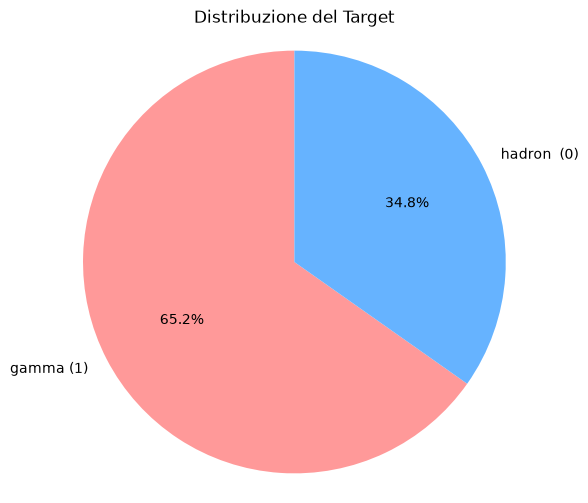

In [17]:
# Diagramma a torta
signal_class = df['class'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(signal_class, labels=['gamma (1)', 'hadron  (0)'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribuzione del Target')
plt.axis('equal')
plt.show()

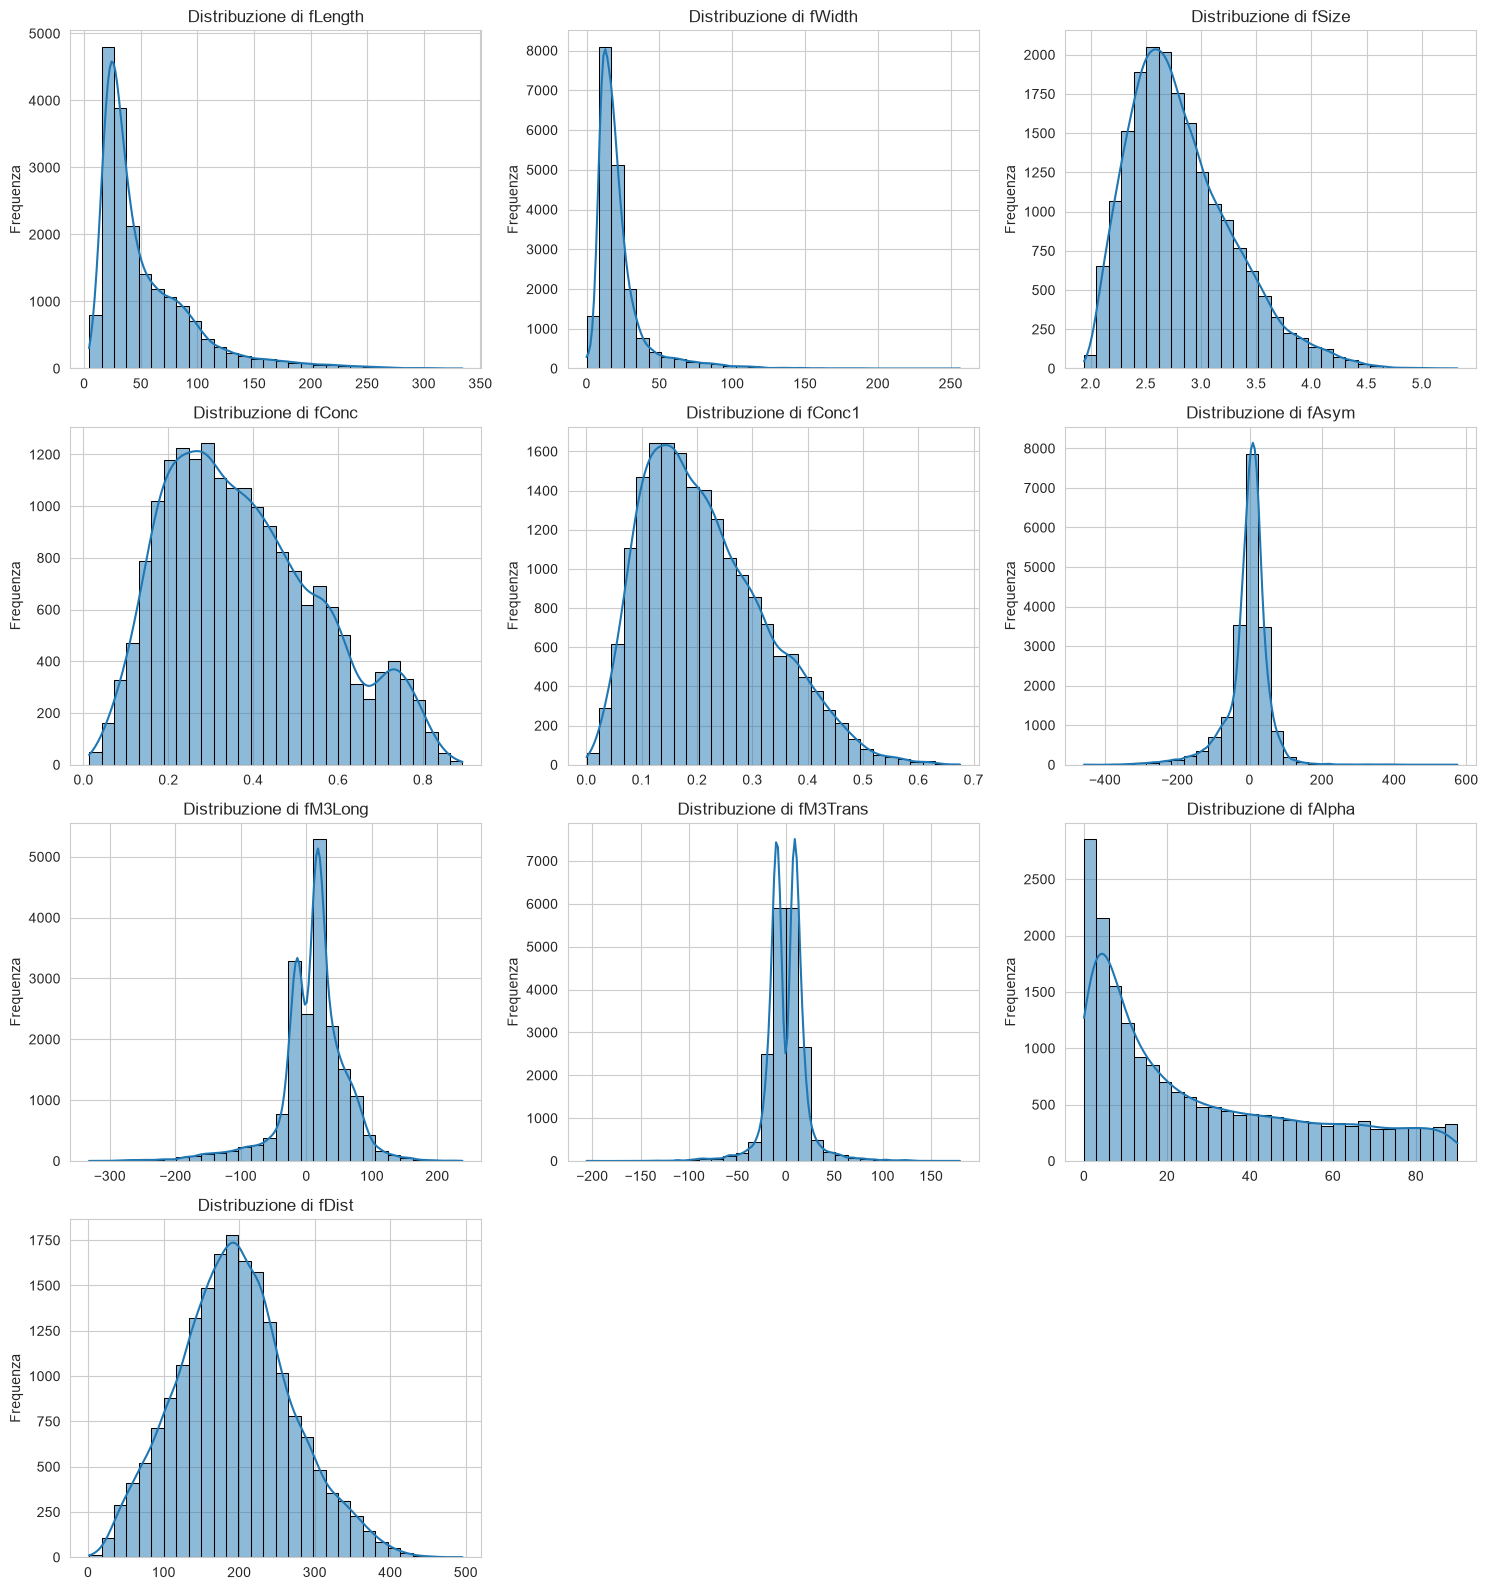

In [18]:
# Istogrammi per le distribuzioni
# Seleziona solo le colonne numeriche ed esclude la target 'class'
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [c for c in numeric_cols if c != 'class']
sns.set_style("whitegrid")
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30, edgecolor='black')
    plt.title(f'Distribuzione di {col}')
    plt.xlabel('')
    plt.ylabel('Frequenza')

plt.tight_layout()
plt.show()

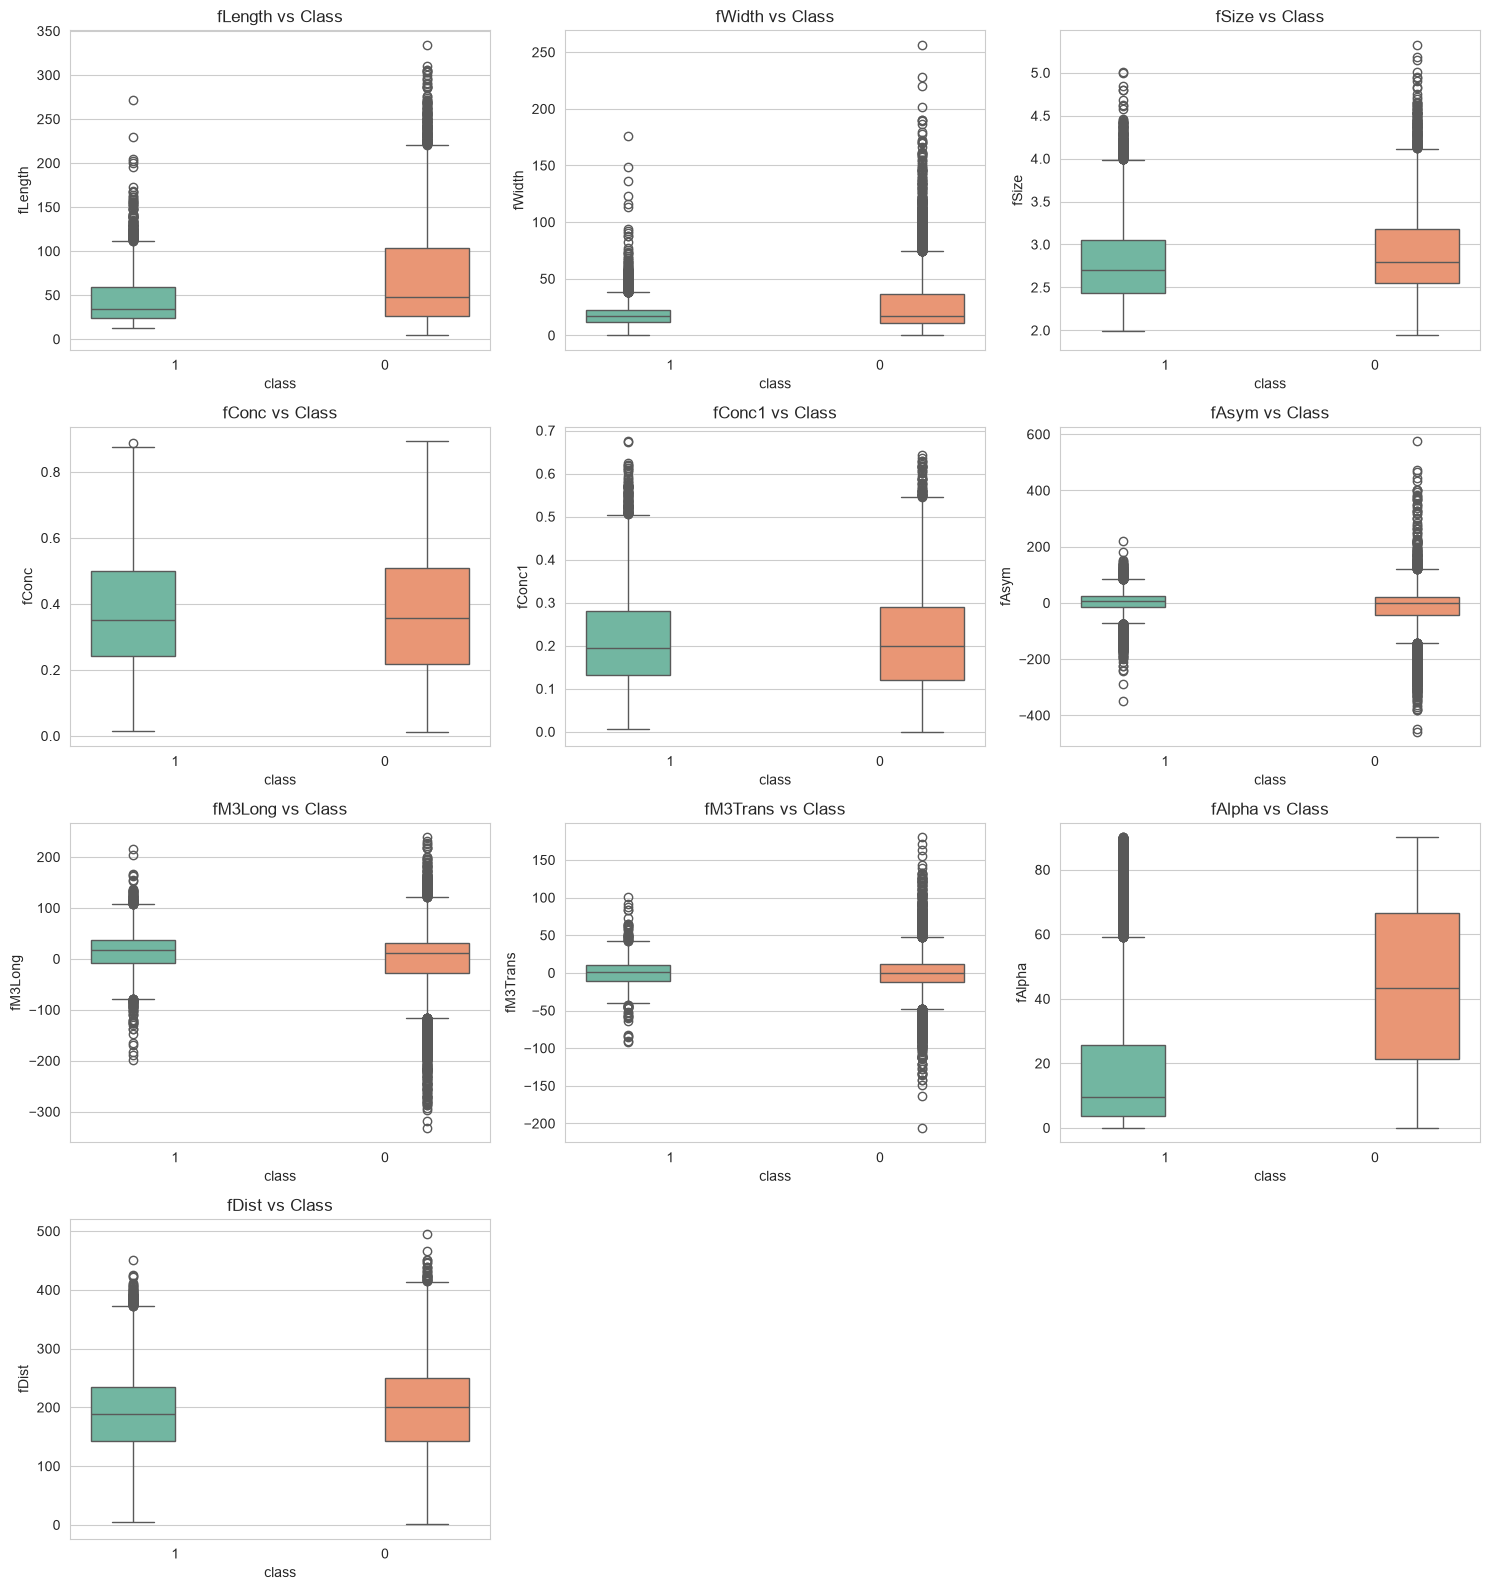

In [19]:
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    # hue='Class' colora diversamente le due specie (0 e 1)
    sns.boxplot(x='class', y=col, hue='class', data=df, palette='Set2',
                legend=False)
    plt.title(f'{col} vs Class')

plt.tight_layout()
plt.show()

##Correlazioni

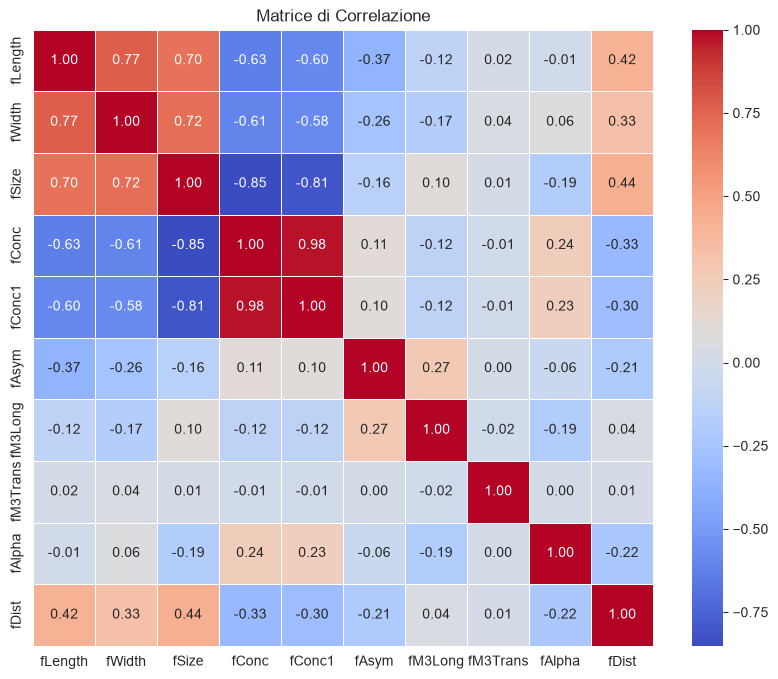

In [20]:
plt.figure(figsize=(10, 8))

# Calcola correlazione di convarianza
corr_matrix = df[numeric_cols].corr()

# Disegna la heatmap
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Matrice di Correlazione')
plt.show()

In [22]:
df_2=df.drop(['fConc'], axis=1)

In [23]:
df_2.dtypes

fLength      float64
fWidth       float64
fSize        float64
fConc1       float64
fAsym        float64
fM3Long      float64
fM3Trans     float64
fAlpha       float64
fDist        float64
class       category
dtype: object

## Split

In [24]:
# Prepariamo X e y dai dati ORIGINALI (non ancora scalati)
X = df_2.drop(['class'], axis=1)
y = df_2['class']
seed=42

# Dividiamo prima di fare qualsiasi calcolo statistico
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=seed,
    stratify=y
)

In [25]:
scaler = StandardScaler()

# Addestriamo lo scaler SOLO sul Train e trasformiamo
X_train_scaled = scaler.fit_transform(X_train)

# Trasformiamo il Test usando le statistiche del Train
X_test_scaled = scaler.transform(X_test)

##PCA

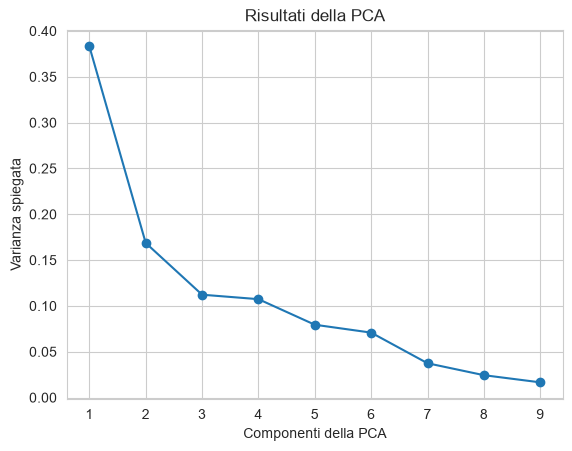

In [26]:
pca = PCA().fit(X_train_scaled)

# Grafico PCA
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_,
         marker='o')
plt.xlabel('Componenti della PCA')
plt.ylabel('Varianza spiegata')
plt.title("Risultati della PCA")
plt.show()

In [27]:
pca.explained_variance_ratio_

array([0.38317193, 0.16864733, 0.11220645, 0.10733634, 0.07944068,
       0.07082748, 0.03740833, 0.02439343, 0.01656803])

In [30]:
def add_gaussian_noise(X, noise_level=0.1, seed=42):
    """
    Aggiunge rumore Gaussiano a un dataset (solo al Train Set).
    """
    if noise_level == 0.0:
        return X.copy()
    
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X.shape)
    return X + noise

# Modelli

In [29]:
# Tutti import che servirà per modelli
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils import class_weight
import tensorflow as tf
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.interpolate import interp1d
import numpy as np

#Rete neurale

In [ ]:
# inizializzazione ottimizzatore:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model = Sequential()

# Aggiunta di layer
model.add(Dense(64, input_shape=(9,), activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=optimizer,
              metrics=['accuracy'])

In [ ]:
# Visualizzazione
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y_train = y_train.astype("int64")
y_test = y_test.astype("int64")

In [ ]:
X_train_scaled.shape

(13233, 9)

In [ ]:
# Addestramento della rete neurale
# EarlyStopping ferma il training se il modello smette di migliorare
early_stop = EarlyStopping(monitor='val_loss', patience=20,
                           restore_best_weights=True)

# Split per cross validation
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=seed
)

# Calcola i pesi inversamente proporzionali alla frequenza per bilanciare
# si usa y_train_new, non tutto y
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_new),
    y=y_train_new
)

class_weights_dict = dict(enumerate(weights))

print(f"Pesi calcolati: {class_weights_dict}")

# Training
history = model.fit(
    X_train_new, y_train_new,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Pesi calcolati: {0: np.float64(1.4379244770442814), 1: np.float64(0.766545981173063)}
Epoch 1/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8756 - loss: 0.3043 - val_accuracy: 0.8440 - val_loss: 0.3593
Epoch 2/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8732 - loss: 0.3144 - val_accuracy: 0.8527 - val_loss: 0.3375
Epoch 3/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 0.3141 - val_accuracy: 0.8440 - val_loss: 0.3505
Epoch 4/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8682 - loss: 0.3120 - val_accuracy: 0.8240 - val_loss: 0.3944
Epoch 5/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8690 - loss: 0.3109 - val_accuracy: 0.8610 - val_loss: 0.3280
Epoch 6/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8749 - loss: 0.3056 - val_accuracy: 0.8436 - val_loss: 0.3514
Epoch 7/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8782 - loss: 0.3010 - val_accuracy: 0.8580 - val_loss: 0.3311
Epoch 8/100

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


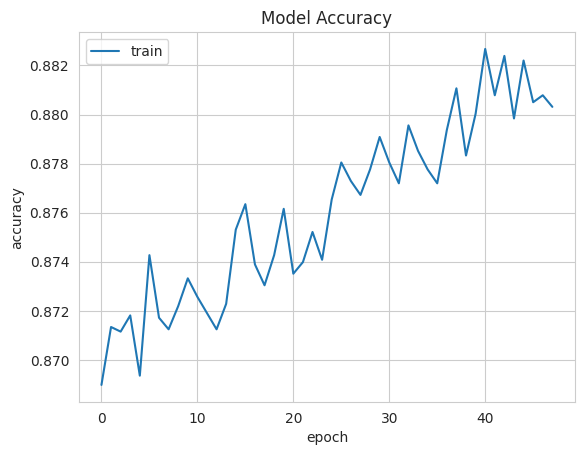

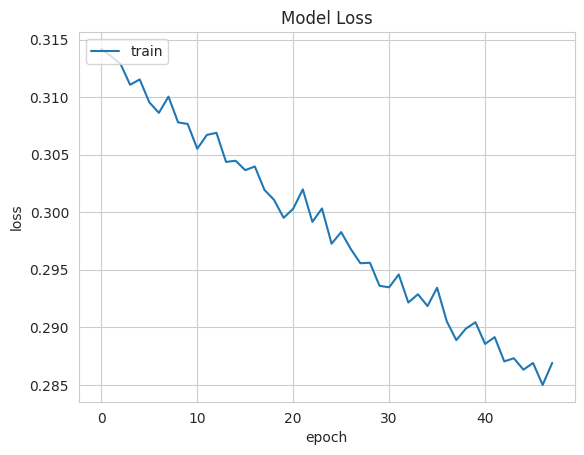

In [ ]:
# Stampa le chiavi per verificare i nomi esatti
print(history.history.keys())
# Grafico dell'accuracy mostrando l'evoluzione dell'accurantezza durante
# il traning
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()
# Grafico della loss
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()

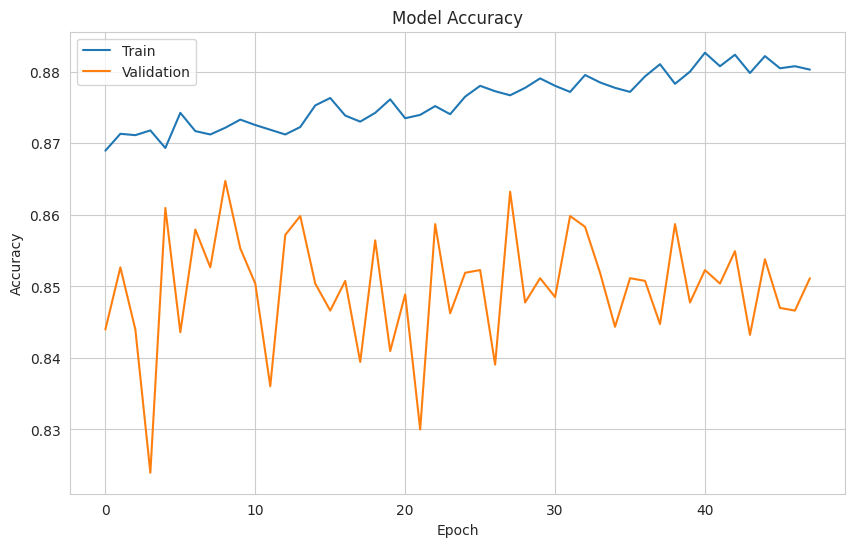

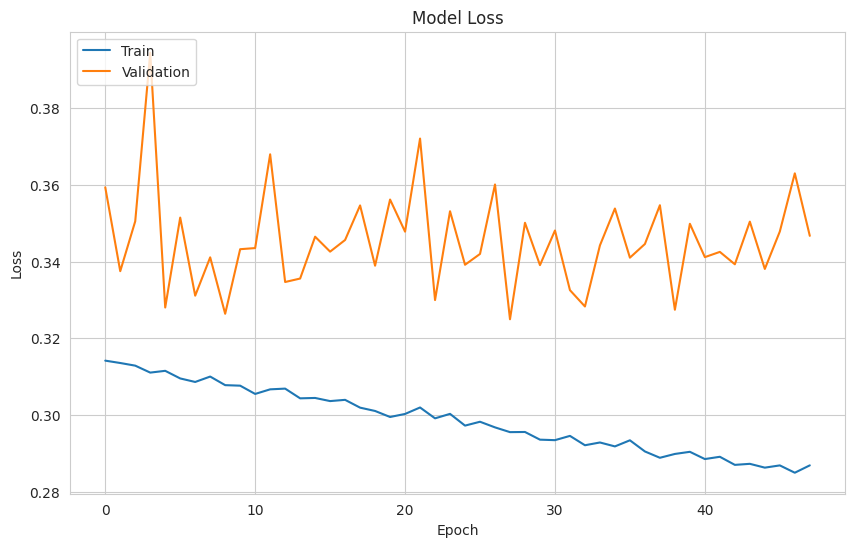

In [ ]:
# Grafico dell'accuracy durante training in confronto con validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

# Grafico della loss durante training in confronto con validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
# Valutazione
score = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test loss: {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

Test loss: 0.3211
Test accuracy: 0.8635


178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


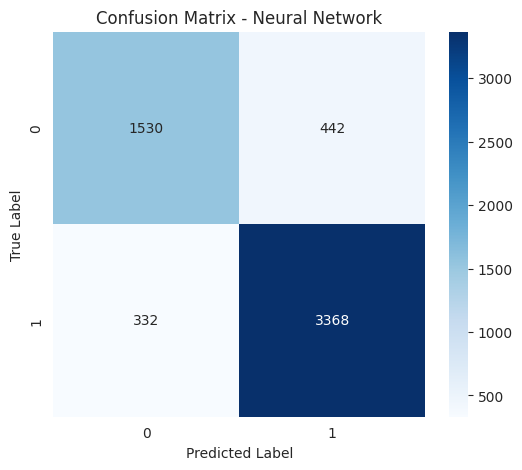


Accuracy finale: 0.8635


In [ ]:
y_pred_probs = model.predict(X_test_scaled)

# Trasforma probabilità in 0 o 1 del target
# Se > 0.5 diventa 1 (Gamma), altrimenti 0 (Hadron)
y_pred_nn = (y_pred_probs > 0.5).astype("int64")

# 3. Calcola la matrice usando le classi convertite
cm = confusion_matrix(y_test, y_pred_nn)

# 4. Disegna il grafico
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Neural Network")
plt.show()

# 5. Stampa l'accuracy
acc = cm.diagonal().sum() / cm.sum()
print(f"\nAccuracy finale: {acc:.4f}")

In [ ]:
# Il report
print(f"Accuratezza Finale Neural Network: {accuracy_score(y_test,
                                                           y_pred_nn):.4f}")
print("\nReport di Classificazione (NN):")
print(classification_report(y_test, y_pred_nn))

Accuratezza Finale Neural Network: 0.8635

Report di Classificazione (NN):
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1972
           1       0.88      0.91      0.90      3700

    accuracy                           0.86      5672
   macro avg       0.85      0.84      0.85      5672
weighted avg       0.86      0.86      0.86      5672



## Confronto performance

178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


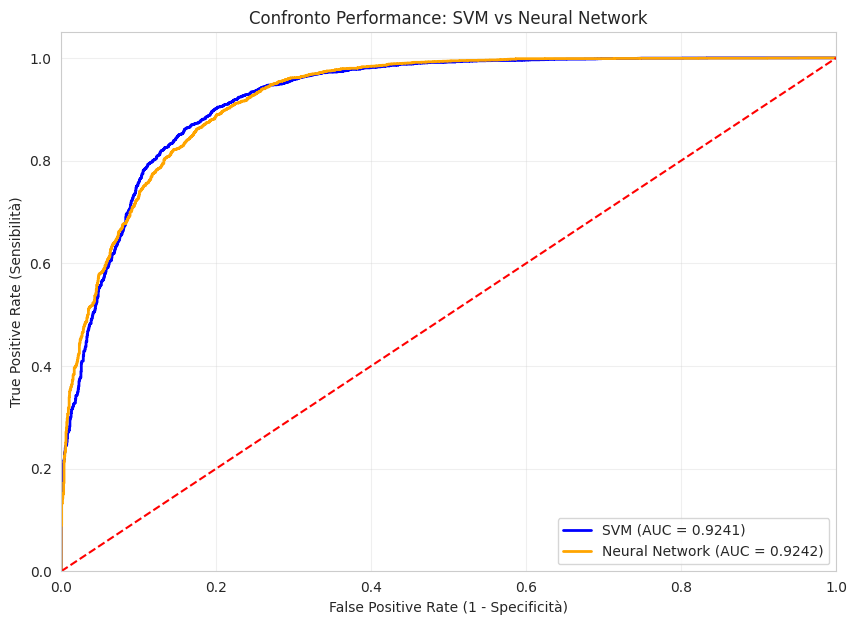

In [ ]:
# Calcolo delle probabilità/punteggi per SVM
# La nostra SVM non ha le probabilità attive (probability = true)
# quindi usiamo la decision_function
y_svm_score = modelSVM.decision_function(X_test_scaled)

y_nn_score = model.predict(X_test_scaled).ravel()

# Calcolo metriche ROC e AUC di SVM e NN
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_svm_score)
auc_svm = roc_auc_score(y_test, y_svm_score)

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_nn_score)
auc_nn = roc_auc_score(y_test, y_nn_score)

# Visualizzazione del confronto
plt.figure(figsize=(10, 7))

plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label=f'SVM (AUC = {auc_svm:.4f})')
plt.plot(fpr_nn, tpr_nn, color='orange', lw=2, label=f'Neural Network (AUC = {auc_nn:.4f})')

# Linea diagonale di riferimento
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificità)')
plt.ylabel('True Positive Rate (Sensibilità)')
plt.title('Confronto Performance: SVM vs Neural Network')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

--- ANALISI COMPARATIVA ---
Punto di intersezione rilevato a FPR ≈ 0.005
Punto di intersezione rilevato a FPR ≈ 0.082
Punto di intersezione rilevato a FPR ≈ 0.269
Punto di intersezione rilevato a FPR ≈ 0.697
Punto di intersezione rilevato a FPR ≈ 0.714
Punto di intersezione rilevato a FPR ≈ 0.740
Punto di intersezione rilevato a FPR ≈ 0.743
Punto di intersezione rilevato a FPR ≈ 0.746
Punto di intersezione rilevato a FPR ≈ 0.748
Punto di intersezione rilevato a FPR ≈ 0.951


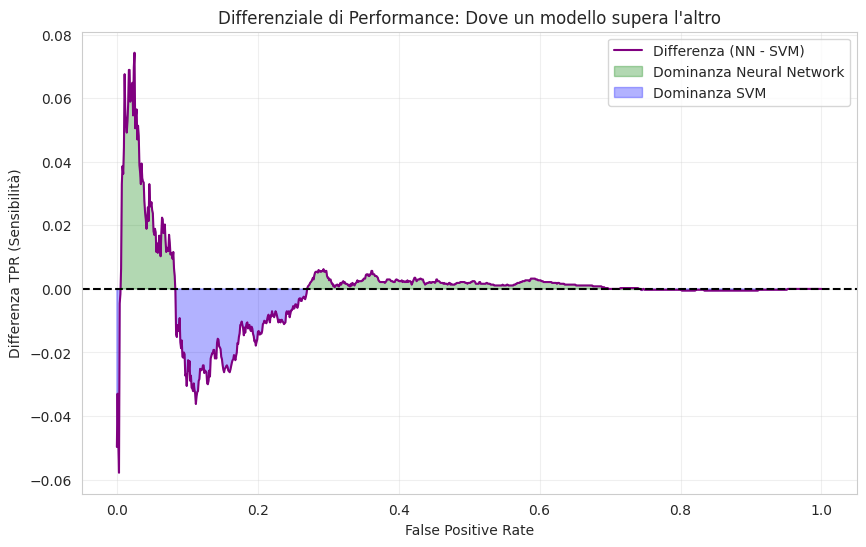

In [ ]:
# Creiamo un range comune di FPR (False Positive Rate) per il confronto
fpr_grid = np.linspace(0, 1, 1000)

# Interpoliamo i TPR (True Positive Rate) di entrambi i modelli sulla stessa griglia
tpr_svm_grid = np.interp(fpr_grid, fpr_svm, tpr_svm)
tpr_nn_grid = np.interp(fpr_grid, fpr_nn, tpr_nn)

# Calcoliamo la differenza (NN - SVM)
# Se > 0, il Decision Tree è sopra (migliore)
# Se < 0, la SVM è sopra (migliore)
diff = tpr_nn_grid - tpr_svm_grid

# Troviamo i punti di intersezione (dove il segno della differenza cambia)
intersections = np.where(np.diff(np.sign(diff)))[0]

print("--- ANALISI COMPARATIVA ---")
for idx in intersections:
    fpr_val = fpr_grid[idx]
    print(f"Punto di intersezione rilevato a FPR ≈ {fpr_val:.3f}")

# Visualizzazione delle aree di dominanza
plt.figure(figsize=(10, 6))
plt.plot(fpr_grid, diff, label='Differenza (NN - SVM)', color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.fill_between(fpr_grid, 0, diff, where=(diff > 0), color='green', alpha=0.3, label='Dominanza Neural Network')
plt.fill_between(fpr_grid, 0, diff, where=(diff < 0), color='blue', alpha=0.3, label='Dominanza SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('Differenza TPR (Sensibilità)')
plt.title('Differenziale di Performance: Dove un modello supera l\'altro')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()